In [4]:
import gzip
import numpy as np
import matplotlib.pyplot as plt

Xs, Ys = [], []
with gzip.open("mapped.bed.gz", "rt") as fh:
    for line in fh:
        cols = line.split("\t")
        s1, e1 = int(cols[2]), int(cols[3])
        s2, e2 = int(cols[8]), int(cols[9])
        center1 = 0.5*(s1+e1)
        center2 = 0.5*(s2+e2)
        Xs.append(center2 - center1)
        Ys.append(e2 - s2)

Xs = np.array(Xs)
Ys = np.array(Ys)
print("Processed", len(Xs), "fragments")
print("X range:", Xs.min(), "to", Xs.max())
print("Y range:", Ys.min(), "to", Ys.max())


Processed 4336134 fragments
X range: -509.0 to 509.5
Y range: 40 to 500


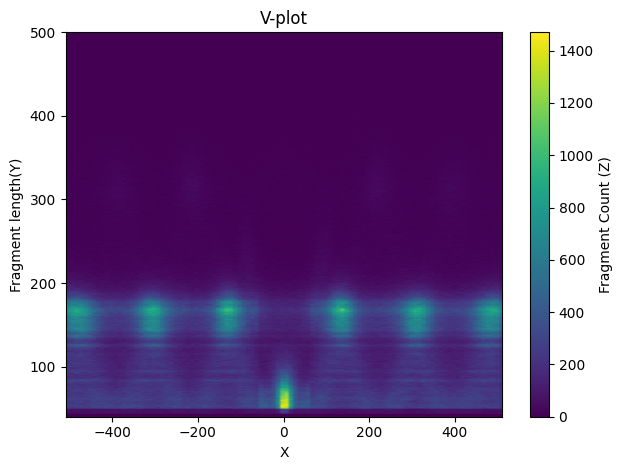

In [5]:
bin_size_x = 10
bin_size_y = 1 

x_bins = np.arange(Xs.min(), Xs.max() + bin_size_x, bin_size_x)
y_bins = np.arange(Ys.min(), Ys.max() + bin_size_y, bin_size_y)

Z, y_edges, x_edges = np.histogram2d(
    Ys,
    Xs,
    bins=[y_bins, x_bins]
)

plt.imshow(
    Z,
    aspect='auto',
    origin='lower',
    extent=(x_edges[0], x_edges[-1], y_edges[0], y_edges[-1]),
    cmap="viridis"
)
plt.colorbar(label="Fragment Count (Z)")
plt.xlabel("X")
plt.ylabel("Fragment length(Y)")
plt.title("V-plot")
plt.tight_layout()
plt.show()